In [1]:
import numpy as np
import scipy.constants
import scipy.sparse
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import math
import geopandas as gpd
import pandas as pd
import os
import netCDF4 as nc

In [2]:
def calc_alongshore_transport_k(gravity=scipy.constants.g, n=1.0, rho_water=1050.0, gamma_b=0.78, ):
    return (
        5.3e-6
        # * 0.46
        * rho_water
        * gravity**1.5
        * (1 / (2 * n)) ** 1.2
        * (np.sqrt(gravity * gamma_b) / (2 * np.pi)) ** 0.2
    )

In [3]:
def get_angles_xr(ds):
    
    ''' Takes average latitude and longitude calculated in beahc_w_to_gps.ipynb and computes bearing using bearing formula
    \(\theta =\>\mathrm{atan2}\>(\sin \Delta \lambda \cdot \cos \phi _{2},\cos \phi _{1}\cdot \sin \phi _{2}-\sin \phi _{1}\cdot \cos \phi _{2}\cdot \cos \Delta \lambda )\)'''
    
    lat = np.radians(ds['mean_lat'])
    lon = np.radians(ds['mean_lon'])

    lat1 = lat.shift(site=1)
    lon1 = lon.shift(site=1)
    lat2 = lat.shift(site=-1)
    lon2 = lon.shift(site=-1)

    dlon = lon2 - lon1
    
    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)

    bearing = np.degrees(np.arctan2(y, x))
    bearing = (bearing + 360) % 360

    return bearing.fillna(0)

In [12]:
def calc_qs(dp, hs, tp, angles, k):

    '''Calculates Q_s using formula from Ashton, Murray 2006 B, equation (7). Negative sign is added so that positive Q_s 
    corresponds to rightward sediment movement when facing offshore (in this case, roughly south-bound).'''
    
    tp_da = tp['tp'] if isinstance(tp, xr.Dataset) else tp # just in case
    hs_da = hs['hs'] if isinstance(hs, xr.Dataset) else hs
    dp_da = dp['dp'] if isinstance(dp, xr.Dataset) else dp

    phi = dp_da - 90
    thet = ((angles + 90) % 360) - 90 # assumes no shoreline bearing angles greater than 270
    angle_term = phi - thet
    angle_term = angle_term.where(angle_term <= 90, angle_term >= -90) # mask areas where waves appear to be moving away from shore
    rad_factor = np.pi / 180
    angle_term = angle_term * rad_factor
    cos_term = np.cos(angle_term)
    sin_term = np.sin(angle_term)
    qs = -k * (tp_da ** .2) * (hs_da ** 2.4) * (cos_term ** 1.2) * sin_term # CERC formula, negative fixes the bearing assumption so that downdrift qs is positive
    # qs = -k * (hs_da ** 2) * cos_term * sin_term # breaking wave formula
    return qs, angle_term

In [6]:
# open dataset
dp = xr.open_dataset('dp_NorthCarolina.nc')
hs = xr.open_dataset('hs_NorthCarolina.nc')
tp = xr.open_dataset('tp_NorthCarolina.nc')
shore = xr.open_dataset('NC_average_lat_lon.nc')

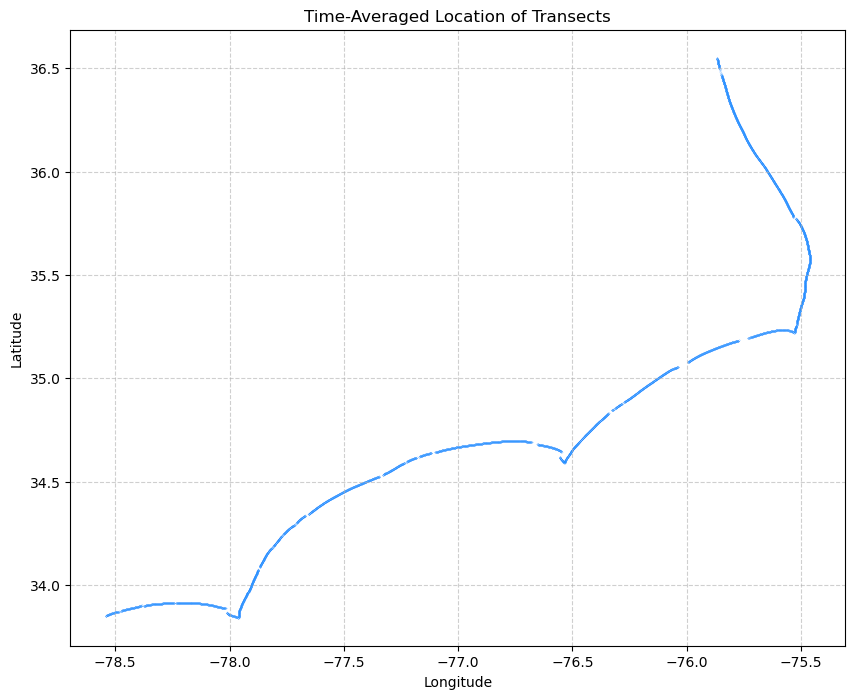

In [8]:
# plot shoreline points
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    shore['mean_lon'].values, 
    shore['mean_lat'].values, 
    s=.01, 
    c='dodgerblue', 
    alpha=0.7
)

ax.set_title('Time-Averaged Location of Transects')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.6)

In [9]:
# compute shoreline angles (bearing from north)
angles_xr = get_angles_xr(shore)

In [11]:
# extends and maps wave data to nearest transect centroid
wave_lats = dp.lat.values
wave_lons = dp.lon.values
transect_lats = shore['mean_lat'].values
transect_lons = shore['mean_lon'].values

def get_nearest_indices(w_lats, w_lons, t_lats, t_lons):
    indices = []
    for lat, lon in zip(t_lats, t_lons):
        dist = np.sqrt((w_lats - lat)**2 + (w_lons - lon)**2)
        indices.append(np.argmin(dist))
    return np.array(indices)

mapping_idx = get_nearest_indices(wave_lats, wave_lons, transect_lats, transect_lons)

dp_mapped = dp.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

hs_mapped = hs.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

tp_mapped = tp.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

In [20]:
# iteratively save nc file
file_name = 'ncqs_hourly_pertransect.nc'
if os.path.exists(file_name):
    os.remove(file_name)

total_time_len = len(dp_mapped.time)

full_template = xr.Dataset(
    data_vars={
        "qs": (("time", "site"), np.zeros((total_time_len, len(angles_xr)), dtype='float32')),
        "angle_diff": (("time", "site"), np.zeros((total_time_len, len(angles_xr)), dtype='float32')),
        "lat": ("site", shore['mean_lat'].values),
        "lon": ("site", shore['mean_lon'].values)
    },
    coords={"time": dp_mapped.time, "site": dp_mapped.site}
)

full_template.to_netcdf(file_name) 

k = calc_alongshore_transport_k()

with nc.Dataset(file_name, 'a') as dst:
    step = 50000
    for i in range(0, total_time_len, step):
        end_idx = min(i + step, total_time_len)
        print(f"Writing indices: {i} to {end_idx}...")
        
        dp_slice = dp_mapped.isel(time=slice(i, end_idx))
        hs_slice = hs_mapped.isel(time=slice(i, end_idx))
        tp_slice = tp_mapped.isel(time=slice(i, end_idx))
        
        qs_slice,angle_slice = calc_qs(dp_slice, hs_slice, tp_slice, angles_xr, k)

        dst['qs'][i:end_idx, :] = qs_slice.values
        dst['angle_diff'][i:end_idx, :] = angle_slice.values

print(f"Saved as {file_name}")

Writing indices: 0 to 50000...
Writing indices: 50000 to 100000...
Writing indices: 100000 to 150000...
Writing indices: 150000 to 200000...
Writing indices: 200000 to 250000...
Writing indices: 250000 to 300000...
Writing indices: 300000 to 350000...
Writing indices: 350000 to 385714...
Saved as ncqs_hourly_pertransect.nc


**Troubleshooting**

In [13]:
# compute and plot all variables for one time slice (plots are all on centroids, not exact transect values)
target_date = "2003-09-03 12:00" 
# rad_factor = np.pi / 180
dp_snapshot = dp_mapped.sel(time=target_date, method='nearest')
phi = dp_snapshot - 90
thet = ((angles_xr + 90) % 360) - 90
angle_snapshot = phi - thet
angle_snapshot = angle_snapshot.where(angle_snapshot <= 90, angle_snapshot >= -90)
hs_snapshot = hs_mapped.sel(time=target_date, method='nearest')
tp_snapshot = tp_mapped.sel(time=target_date, method='nearest')

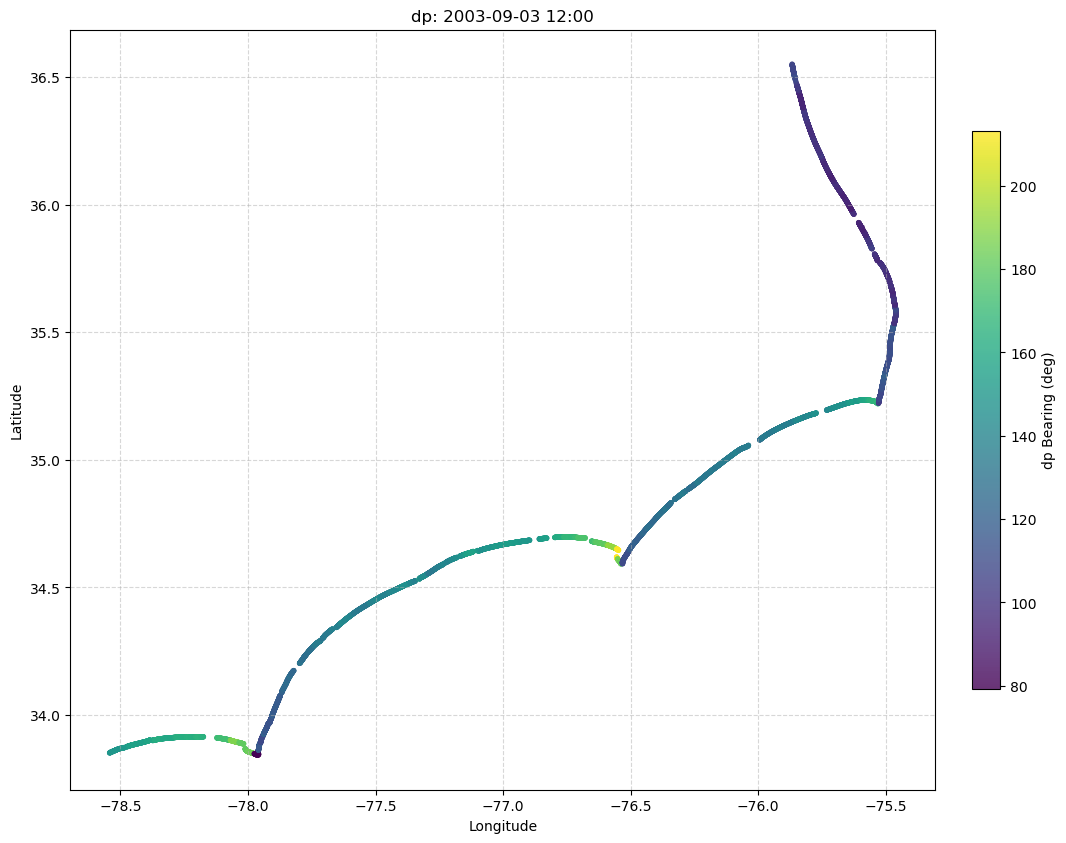

In [14]:
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    shore['mean_lon'].values, 
    shore['mean_lat'].values, 
    c=dp_snapshot['dp'].values,  # <--- Access the variable name here
    cmap='viridis', 
    s=15, 
    alpha=0.8,
    edgecolors='none'
)

cbar = fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("dp Bearing (deg)")

ax.set_title(f"dp: {target_date}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect('equal') # Keeps the coastal geography from looking squashed
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

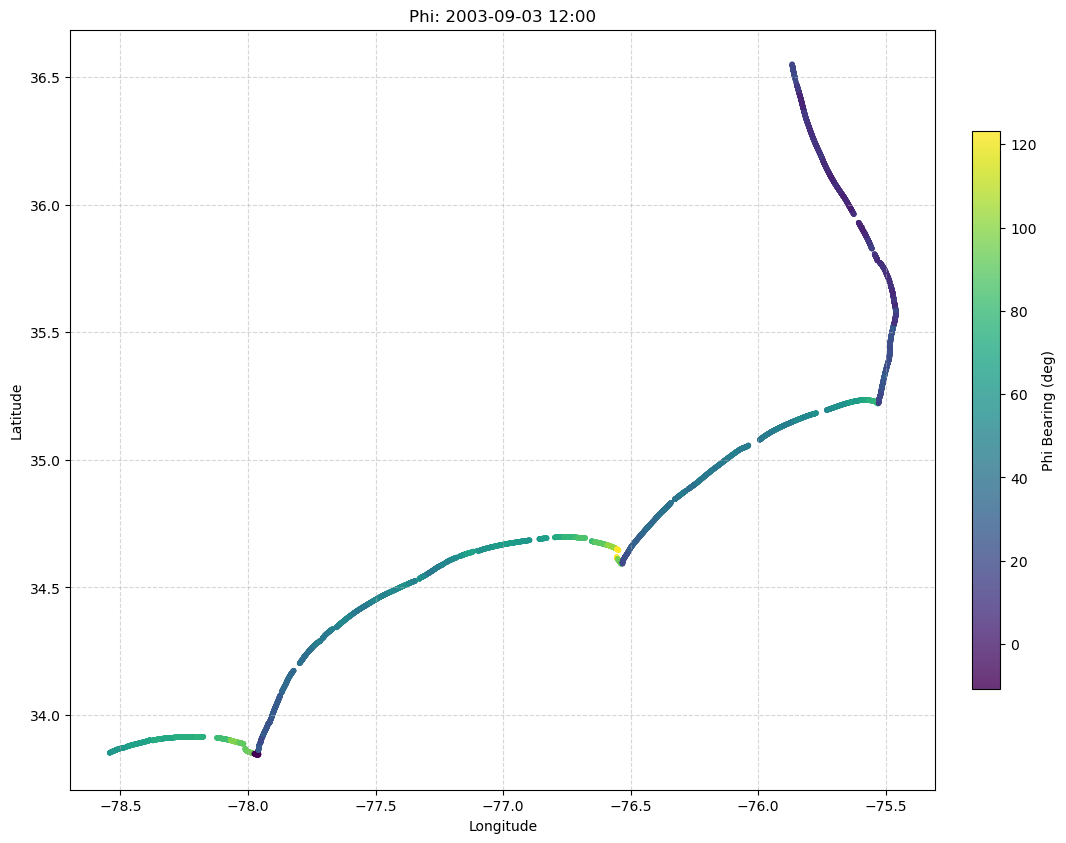

In [15]:
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    shore['mean_lon'].values, 
    shore['mean_lat'].values, 
    c=phi['dp'].values,  # <--- Access the variable name here
    cmap='viridis', 
    s=15, 
    alpha=0.8,
    edgecolors='none'
)

cbar = fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Phi Bearing (deg)")

ax.set_title(f"Phi: {target_date}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect('equal') # Keeps the coastal geography from looking squashed
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

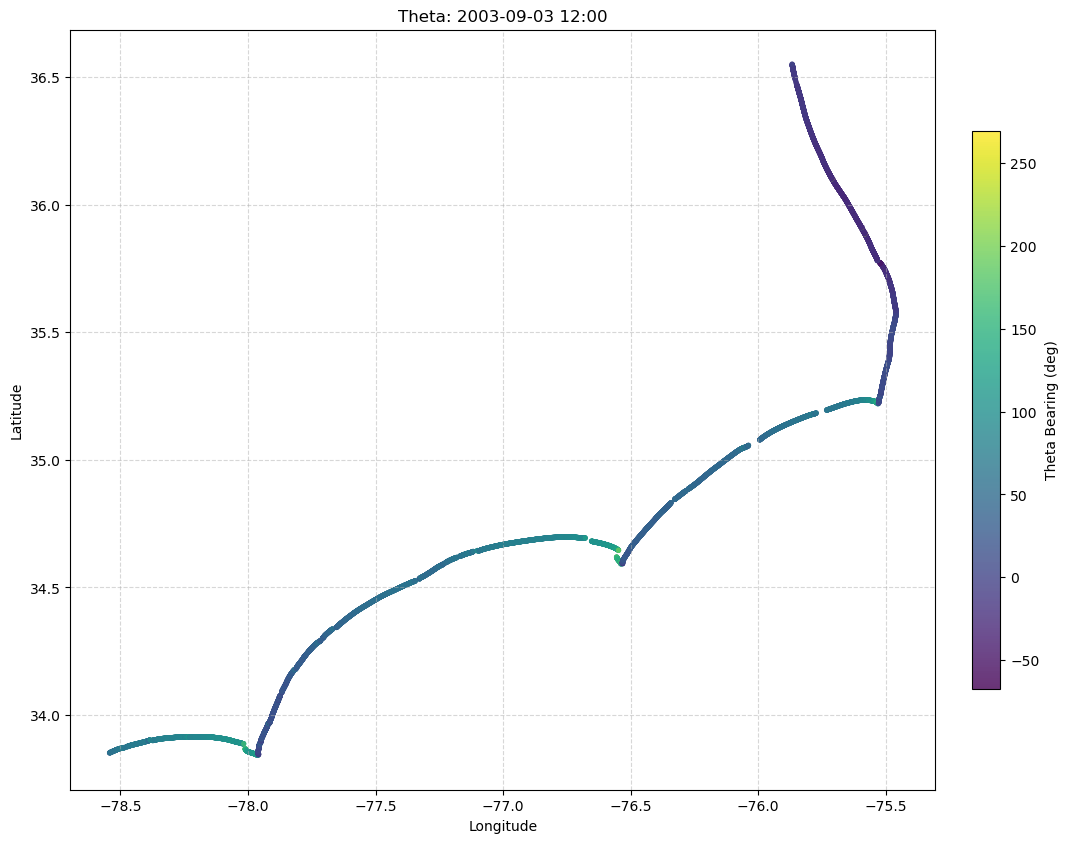

In [16]:
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    shore['mean_lon'].values, 
    shore['mean_lat'].values, 
    c=thet.values,  # <--- Access the variable name here
    cmap='viridis', 
    s=15, 
    alpha=0.8,
    edgecolors='none'
)

cbar = fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Theta Bearing (deg)")

ax.set_title(f"Theta: {target_date}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect('equal') # Keeps the coastal geography from looking squashed
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

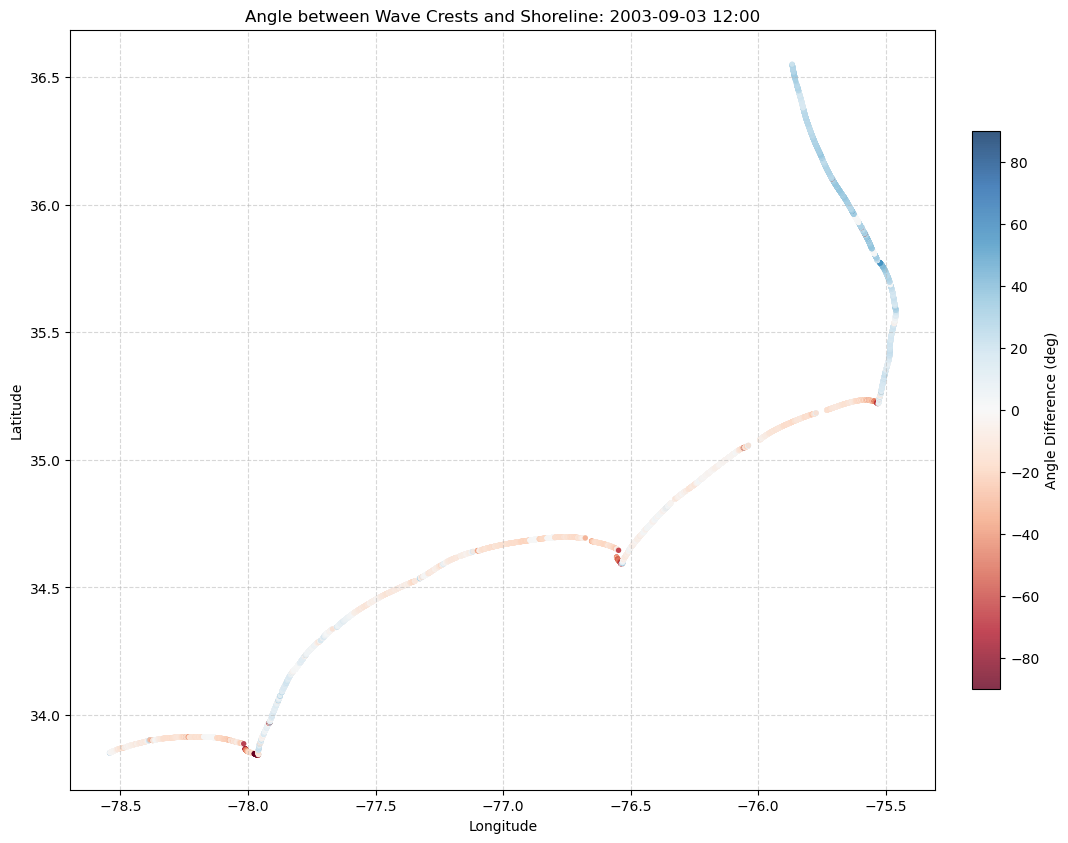

In [17]:
fig, ax = plt.subplots(figsize=(12, 10))

norm = mcolors.CenteredNorm(halfrange=90)

scatter = ax.scatter(
    shore['mean_lon'].values, 
    shore['mean_lat'].values, 
    c=angle_snapshot['dp'].values,  # <--- Access the variable name here
    norm=norm,
    cmap='RdBu', 
    s=15, 
    alpha=0.8,
    edgecolors='none'
)

cbar = fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("Angle Difference (deg)")

ax.set_title(f"Angle between Wave Crests and Shoreline: {target_date}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect('equal') # Keeps the coastal geography from looking squashed
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [18]:
# calculate qs
k = calc_alongshore_transport_k()
tp_da = tp_snapshot['tp'] 
hs_da = hs_snapshot['hs']

rad_factor = np.pi / 180
angle_term = angle_snapshot * rad_factor
cos_term = np.cos(angle_term)
sin_term = np.sin(angle_term)
qs_da = -k * (tp_da ** .2) * (hs_da ** 2.4) * (cos_term ** 1.2) * sin_term

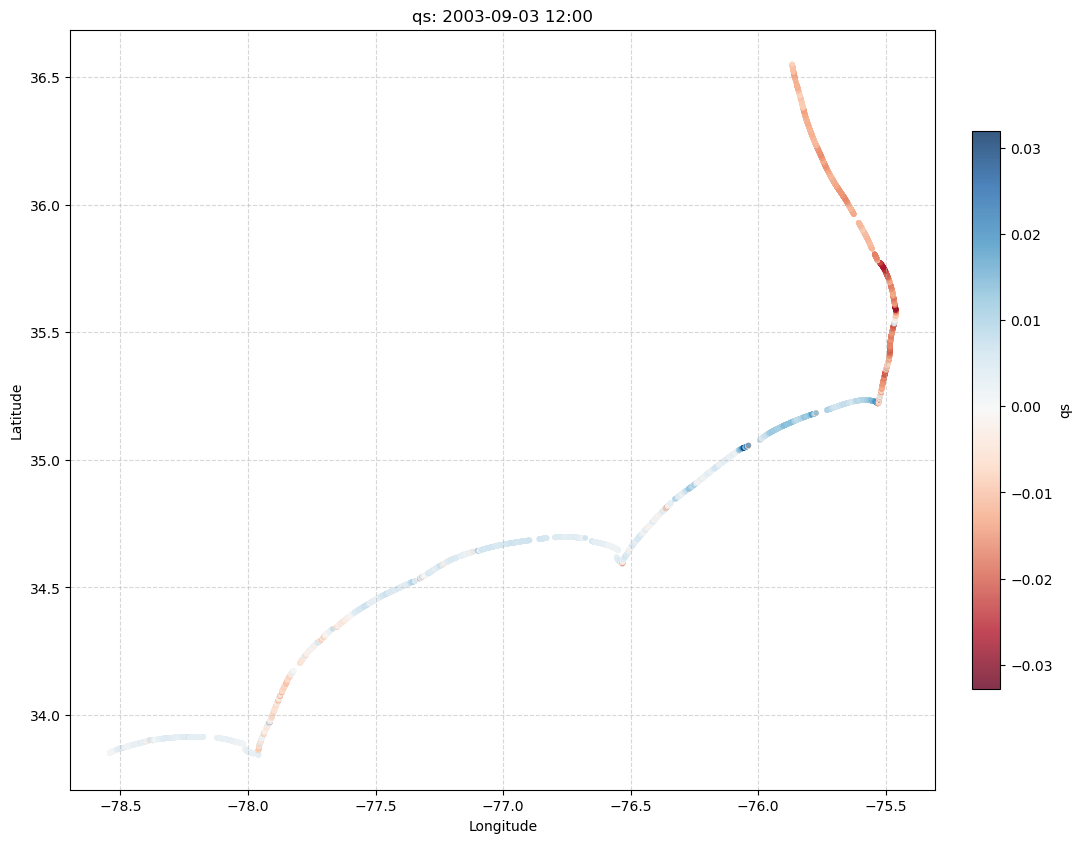

In [19]:
fig, ax = plt.subplots(figsize=(12, 10))

scatter = ax.scatter(
    shore['mean_lon'].values, 
    shore['mean_lat'].values, 
    c=qs_da['dp'].values,  # <--- Access the variable name here
    cmap='RdBu', 
    s=15, 
    alpha=0.8,
    edgecolors='none'
)

cbar = fig.colorbar(scatter, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label("qs")

ax.set_title(f"qs: {target_date}")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect('equal') # Keeps the coastal geography from looking squashed
ax.grid(True, linestyle='--', alpha=0.5)

plt.show()